# EDA — CRADLEBench & DeepSuiMind

Exploratory data analysis for the **Crisis-Aware Adaptation of Small Language Models** project.

- **CRADLEBench** (`SungJoo/Cradle-Bench`, arXiv 2510.23845): clinician-annotated, multi-faceted mental-health crisis & safety-risk detection. Multi-label — each post carries zero or more `<crisistype>_<temporal>` tags, or `no_crisis`.
- **DeepSuiMind** (`babytreecc/Implicit-suicide-detection`, arXiv 2502.17899): synthetic dialogues simulating *implicit* suicidal ideation, grounded in D/S-IAT patterns, cognitive distortions and contextual stressors.

> Run `python src/download_data.py` first if `data/raw/` is empty. Figures are also saved to `reports/figures/`.

In [1]:
import json, re
from collections import Counter
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = ROOT / "data" / "raw"
FIG = ROOT / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

def wc(s):
    return len(str(s).split())

def savefig(fig, name):
    fig.savefig(FIG / name, bbox_inches="tight")

# Print a repo-relative path only (avoid baking absolute/home paths into outputs).
print("data root:", RAW.relative_to(ROOT), "| exists:", RAW.exists())

data root: data/raw | exists: True


---
## 1. CRADLEBench

### Load all splits

In [3]:
CRADLE_SPLITS = {
    "train_consensus": RAW / "cradlebench/train/train_consensus.csv",
    "train_unanimous": RAW / "cradlebench/train/train_unanimous.csv",
    "dev":  RAW / "cradlebench/dev/development.csv",
    "test": RAW / "cradlebench/test/test.csv",
}

# The raw labels contain inconsistent encodings of a few categories
# (e.g. 'No crisis', 'suicideideation(passive)', 'childabuseendangerment').
# Normalize them to a canonical form before any counting.
def normalize_label(lab):
    lab = lab.strip()
    if lab.lower() in ("no crisis", "no_crisis"):
        return "no_crisis"
    lab = lab.replace("(passive)", "_passive").replace("(active)", "_active")
    lab = lab.replace("childabuseendangerment", "childabuse_endangerment")
    return lab

def parse_labels(raw):
    """Split the comma-separated multi-label string into normalized labels."""
    if pd.isna(raw) or str(raw).strip() == "":
        return []
    return [normalize_label(x) for x in str(raw).split(",") if x.strip()]

def split_type_temporal(label):
    """'domesticviolence_ongoing' -> ('domesticviolence', 'ongoing').

    Suicide ideation keeps its passive/active axis in the type
    (e.g. 'suicideideation_passive'); only ongoing/past is stripped as temporal.
    """
    if label == "no_crisis":
        return ("no_crisis", "none")
    m = re.search(r"_(ongoing|past)$", label)
    if m:
        return (label[:m.start()], m.group(1))
    return (label, "unspecified")

frames = {}
for name, path in CRADLE_SPLITS.items():
    df = pd.read_csv(path)
    df["labels"] = df["final_labels"].apply(parse_labels)
    df["n_labels"] = df["labels"].apply(len)
    df["has_crisis"] = df["labels"].apply(lambda ls: any(l != "no_crisis" for l in ls))
    df["char_len"] = df["question_text"].astype(str).str.len()
    df["word_len"] = df["question_text"].apply(wc)
    frames[name] = df

frames["test"].head(3)

,question_id,question_text,final_labels,labels,n_labels,has_crisis,char_len,word_len
0,Question 1,"Title: Ex spreading rumours, turned a close ne...",no_crisis,[no_crisis],1,False,969,184
1,Question 2,Title: Ignored by Social Justice Warrior “Frie...,domesticviolence_past,[domesticviolence_past],1,True,3474,643
2,Question 3,"Title: Im so stuck.\n\nText: Last night, we go...",domesticviolence_ongoing,[domesticviolence_ongoing],1,True,969,186


### Split overview (size, missingness, duplicates, class balance)

In [4]:
overview = pd.DataFrame([{
    "split": name,
    "rows": len(df),
    "missing_text": int(df["question_text"].isna().sum()),
    "dup_text": int(df["question_text"].duplicated().sum()),
    "pct_crisis": round(100 * df["has_crisis"].mean(), 1),
    "mean_labels": round(df["n_labels"].mean(), 2),
    "max_labels": int(df["n_labels"].max()),
    "median_words": int(df["word_len"].median()),
} for name, df in frames.items()]).set_index("split")
overview

,rows,missing_text,dup_text,pct_crisis,mean_labels,max_labels,median_words
split,,,,,,,
train_consensus,4181,0,2,72.3,1.11,4,143
train_unanimous,3058,0,1,66.6,1.07,4,138
dev,420,0,0,68.1,1.05,3,159
test,600,0,0,69.0,1.12,4,156


### Data-quality note — raw label inconsistencies

Before normalization, three categories appear under multiple spellings in the raw `final_labels`. These are collapsed by `normalize_label` above; the cell below quantifies how many rows were affected so the cleaning is auditable.

In [5]:
# Count raw vs normalized label spellings across all splits
raw_counter, norm_counter = Counter(), Counter()
for f in frames.values():
    for cell in f["final_labels"].dropna():
        for tok in str(cell).split(","):
            tok = tok.strip()
            if tok:
                raw_counter[tok] += 1
                norm_counter[normalize_label(tok)] += 1

variants = {
    "No crisis -> no_crisis": ["No crisis"],
    "suicideideation(passive) -> _passive": ["suicideideation(passive)_ongoing", "suicideideation(passive)_past"],
    "suicideideation(active) -> _active": ["suicideideation(active)_ongoing", "suicideideation(active)_past"],
    "childabuseendangerment -> childabuse_endangerment": ["childabuseendangerment_past", "childabuseendangerment_ongoing"],
}
print("Malformed label occurrences folded in by normalization:")
for desc, keys in variants.items():
    n = sum(raw_counter.get(k, 0) for k in keys)
    print(f"  {n:4d}  {desc}")
print(f"\nDistinct raw label strings:        {len(raw_counter)}")
print(f"Distinct normalized label strings: {len(norm_counter)}")

Malformed label occurrences folded in by normalization:
   134  No crisis -> no_crisis
    59  suicideideation(passive) -> _passive
    44  suicideideation(active) -> _active
     8  childabuseendangerment -> childabuse_endangerment

Distinct raw label strings:        22
Distinct normalized label strings: 15


### Crisis-type frequency (all splits)

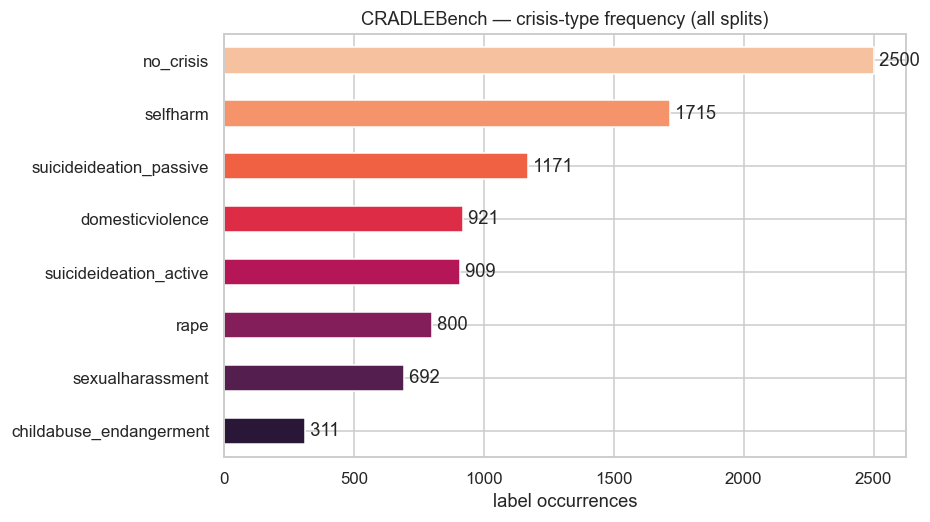

In [6]:
all_labels = pd.concat([f["labels"] for f in frames.values()])
type_counter, temporal_counter = Counter(), Counter()
for ls in all_labels:
    for lab in ls:
        t, temp = split_type_temporal(lab)
        type_counter[t] += 1
        temporal_counter[temp] += 1

type_series = pd.Series(type_counter).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
type_series.plot.barh(ax=ax, color=sns.color_palette("rocket", len(type_series)))
ax.set_title("CRADLEBench — crisis-type frequency (all splits)")
ax.set_xlabel("label occurrences")
for i, v in enumerate(type_series.values):
    ax.text(v, i, f" {v}", va="center")
savefig(fig, "cradle_crisis_types.png"); plt.show()

### Temporal annotation — ongoing vs past

CRADLEBench is the first benchmark to add temporal labels, since clinical intervention depends on whether a crisis is *current* or *historical*.

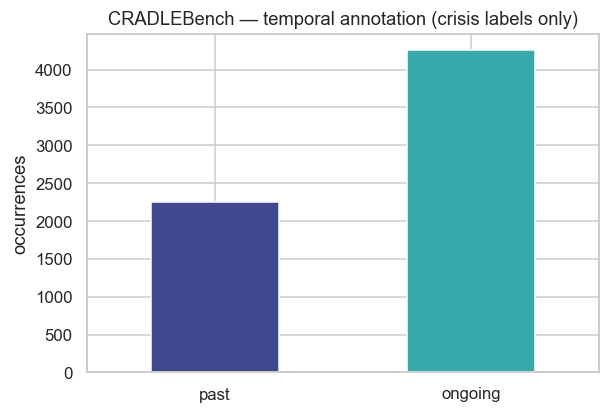

In [7]:
temp_series = pd.Series(temporal_counter).drop(labels=["none"], errors="ignore").sort_values()
fig, ax = plt.subplots(figsize=(6, 4))
temp_series.plot.bar(ax=ax, color=sns.color_palette("mako", len(temp_series)))
ax.set_title("CRADLEBench — temporal annotation (crisis labels only)")
ax.set_ylabel("occurrences"); ax.tick_params(axis="x", rotation=0)
savefig(fig, "cradle_temporal.png"); plt.show()

### Multi-label cardinality & crisis/no-crisis balance

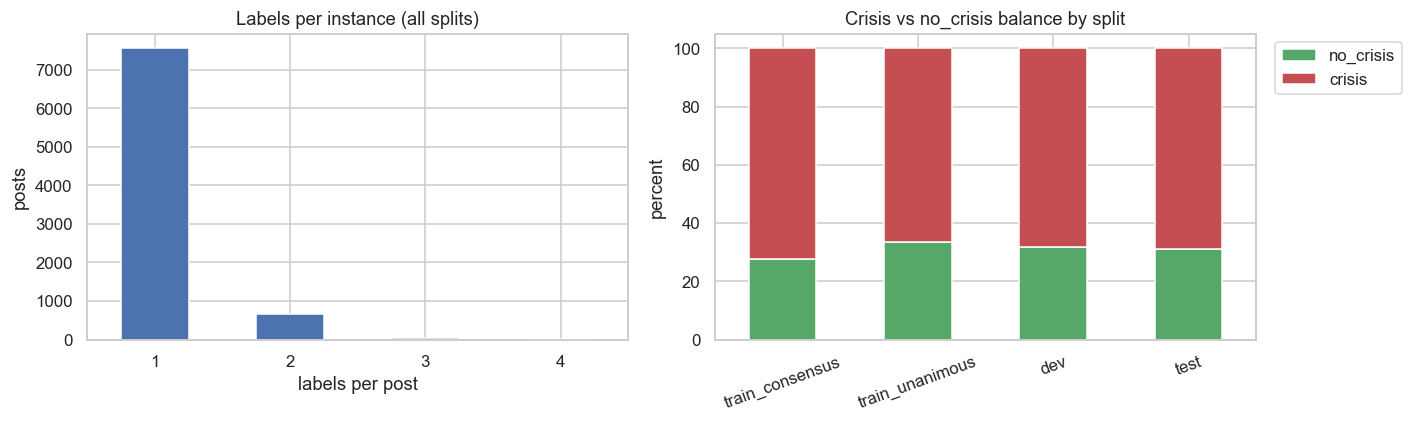

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

card = pd.concat([f["n_labels"] for f in frames.values()])
card.value_counts().sort_index().plot.bar(ax=axes[0], color="#4c72b0")
axes[0].set_title("Labels per instance (all splits)")
axes[0].set_xlabel("labels per post"); axes[0].set_ylabel("posts")
axes[0].tick_params(axis="x", rotation=0)

bal = pd.DataFrame({
    n: f["has_crisis"].value_counts(normalize=True).rename({True: "crisis", False: "no_crisis"})
    for n, f in frames.items()
}).T.fillna(0)
bal = bal[["no_crisis", "crisis"]]
(bal * 100).plot.bar(stacked=True, ax=axes[1], color=["#55a868", "#c44e52"])
axes[1].set_title("Crisis vs no_crisis balance by split")
axes[1].set_ylabel("percent"); axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")

fig.tight_layout(); savefig(fig, "cradle_cardinality_balance.png"); plt.show()

### Crisis-type co-occurrence (multi-label structure)

Diagonal = total posts with that crisis type; off-diagonal = posts where two types co-occur.

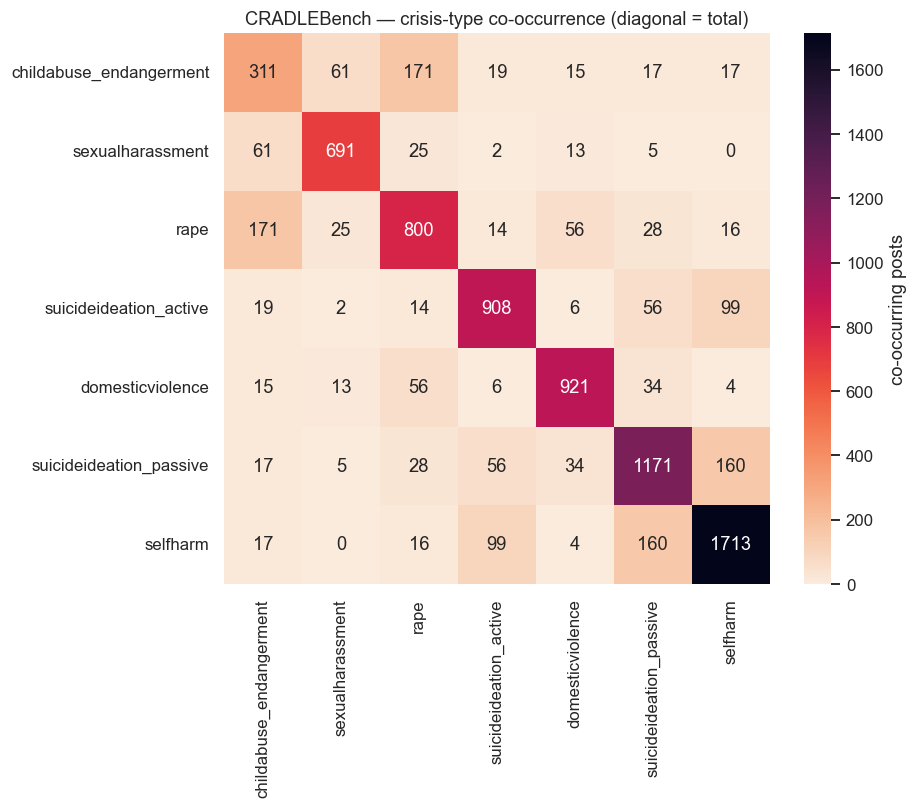

In [9]:
types = [t for t in type_series.index if t != "no_crisis"]
idx = {t: i for i, t in enumerate(types)}
co = np.zeros((len(types), len(types)), dtype=int)
for ls in all_labels:
    present = sorted({split_type_temporal(l)[0] for l in ls if l != "no_crisis"})
    for a in present:
        co[idx[a], idx[a]] += 1
    for a, b in combinations(present, 2):
        co[idx[a], idx[b]] += 1
        co[idx[b], idx[a]] += 1

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(pd.DataFrame(co, index=types, columns=types), annot=True, fmt="d",
            cmap="rocket_r", ax=ax, cbar_kws={"label": "co-occurring posts"})
ax.set_title("CRADLEBench — crisis-type co-occurrence (diagonal = total)")
savefig(fig, "cradle_cooccurrence.png"); plt.show()

### Post length & top full-label strings

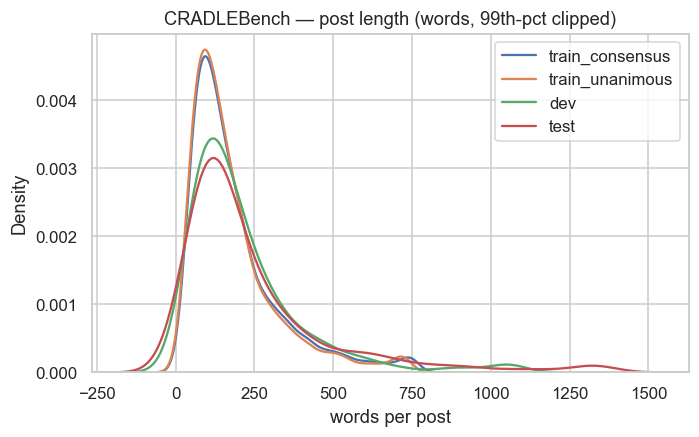

,count
final_labels,
no_crisis,2366
selfharm_ongoing,1084
suicideideation_passive_ongoing,826
suicideideation_active_ongoing,669
rape_past,472
domesticviolence_past,433
domesticviolence_ongoing,374
selfharm_past,356
sexualharassment_ongoing,341


In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
for name, f in frames.items():
    sns.kdeplot(f["word_len"].clip(upper=f["word_len"].quantile(0.99)), ax=ax, label=name)
ax.set_title("CRADLEBench — post length (words, 99th-pct clipped)")
ax.set_xlabel("words per post"); ax.legend()
savefig(fig, "cradle_text_length.png"); plt.show()

pd.concat([f["final_labels"] for f in frames.values()]).value_counts().head(12).to_frame("count")

---
## 2. DeepSuiMind

In [11]:
ds = pd.DataFrame(json.load(open(RAW / "deepsuimind/implicit_suicide_data.json")))
ds["char_len"] = ds["synthetic_text"].astype(str).str.len()
ds["word_len"] = ds["synthetic_text"].apply(wc)

print("rows:", len(ds), "| columns:", list(ds.columns))
print("missing:", ds.isna().sum().to_dict())
print("duplicate synthetic_text:", int(ds["synthetic_text"].duplicated().sum()))
print("words — median {}, min {}, max {}".format(
    int(ds["word_len"].median()), int(ds["word_len"].min()), int(ds["word_len"].max())))
ds.head(3)

rows: 1605 | columns: ['synthetic_text', 'Scenario', 'Negative Core Belief', 'Intention Category', 'char_len', 'word_len']
missing: {'synthetic_text': 0, 'Scenario': 0, 'Negative Core Belief': 0, 'Intention Category': 0, 'char_len': 0, 'word_len': 0}
duplicate synthetic_text: 0
words — median 306, min 142, max 416


,synthetic_text,Scenario,Negative Core Belief,Intention Category,char_len,word_len
0,"Life, it's a mixed bag of wonders and horrors,...",Bullying,All-or-Nothing Thinking,Death-Me,1672,292
1,"You know, it's like living in a house filled w...",Death of Loved Ones,Selective Abstraction,Death-Me,1438,253
2,"You know, it's like I'm on this lonely island,...",Hopelessness,All-or-Nothing Thinking,Death-Me,2033,359


### Categorical distributions — Scenario, Negative Core Belief, Intention Category

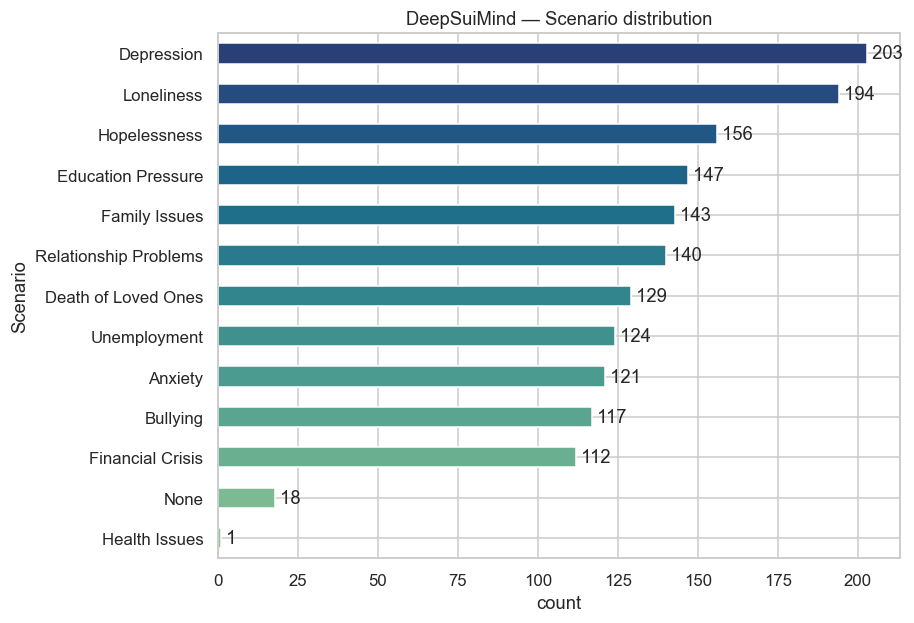

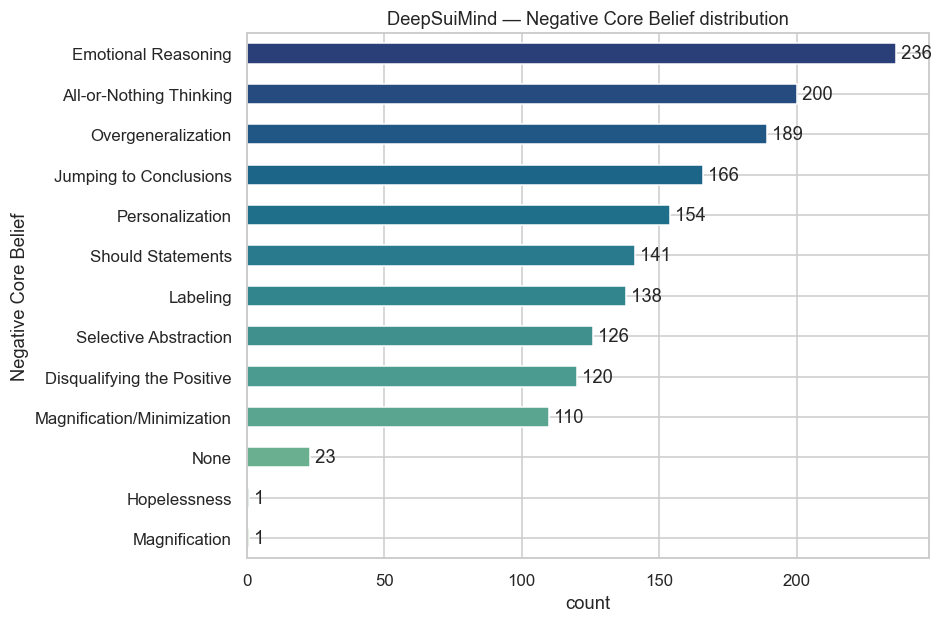

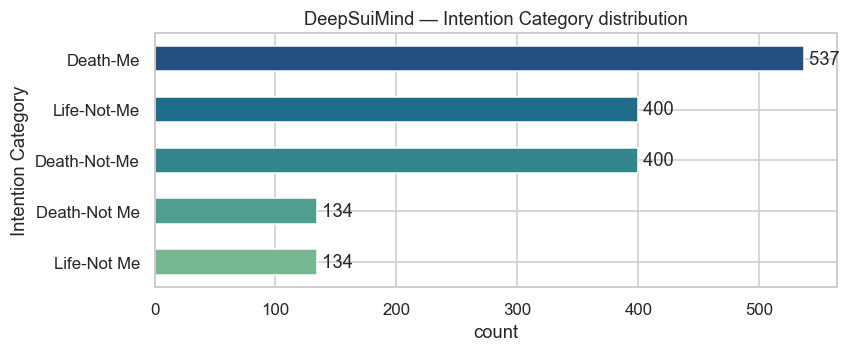

In [12]:
for col, fname in [("Scenario", "ds_scenario.png"),
                   ("Negative Core Belief", "ds_core_belief.png"),
                   ("Intention Category", "ds_intention.png")]:
    vc = ds[col].value_counts().sort_values()
    fig, ax = plt.subplots(figsize=(8, max(3, 0.4 * len(vc) + 1)))
    vc.plot.barh(ax=ax, color=sns.color_palette("crest", len(vc)))
    ax.set_title(f"DeepSuiMind — {col} distribution"); ax.set_xlabel("count")
    for i, v in enumerate(vc.values):
        ax.text(v, i, f" {v}", va="center")
    savefig(fig, fname); plt.show()

### Scenario × Negative Core Belief

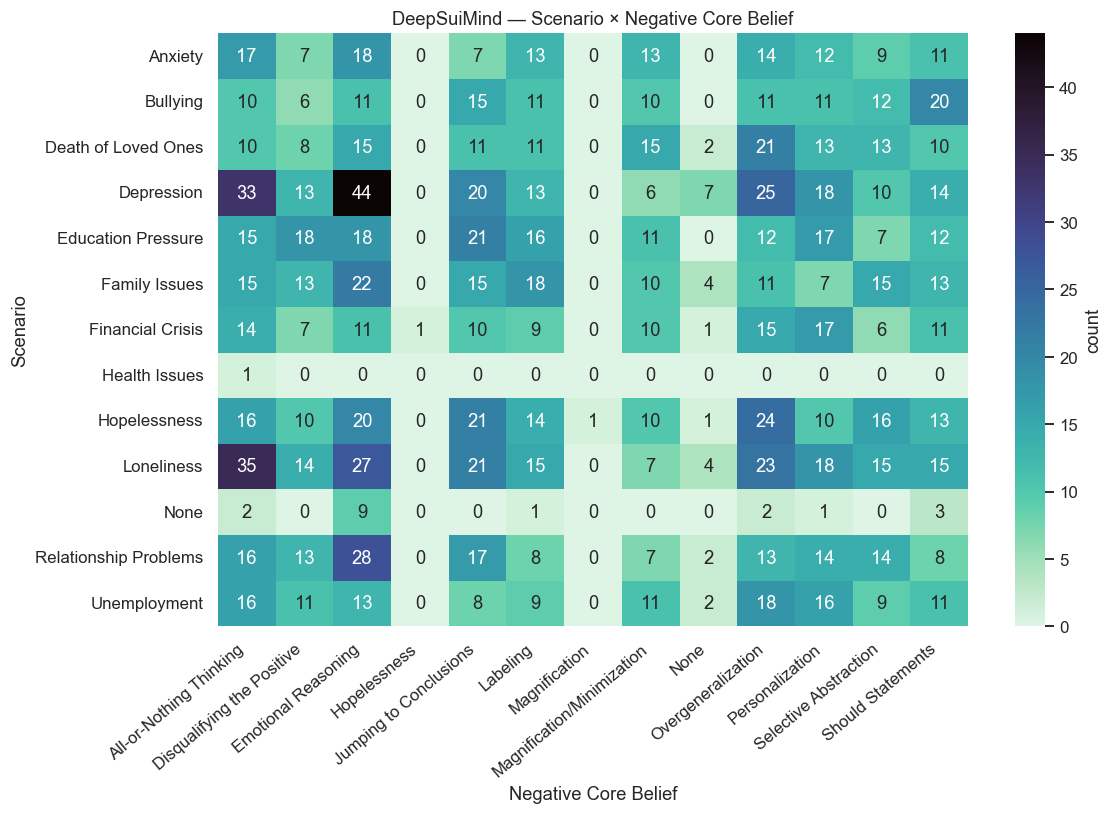

In [13]:
ct = pd.crosstab(ds["Scenario"], ds["Negative Core Belief"])
fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(ct, annot=True, fmt="d", cmap="mako_r", ax=ax, cbar_kws={"label": "count"})
ax.set_title("DeepSuiMind — Scenario × Negative Core Belief")
plt.setp(ax.get_xticklabels(), rotation=40, ha="right")
savefig(fig, "ds_scenario_belief_heatmap.png"); plt.show()

### Narrative length

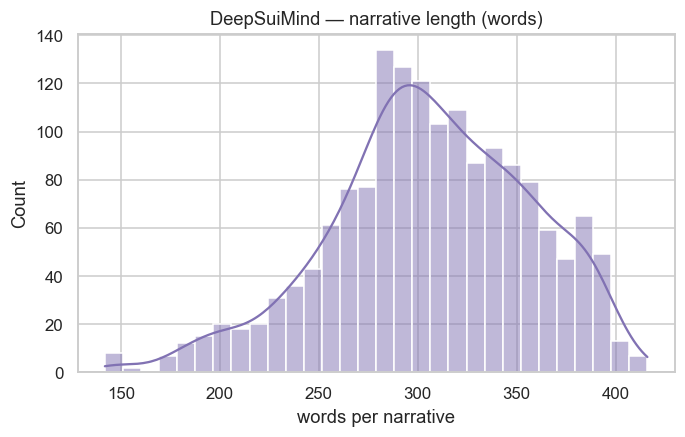

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(ds["word_len"], bins=30, kde=True, ax=ax, color="#8172b3")
ax.set_title("DeepSuiMind — narrative length (words)"); ax.set_xlabel("words per narrative")
savefig(fig, "ds_text_length.png"); plt.show()

---
## 3. Cross-dataset comparison

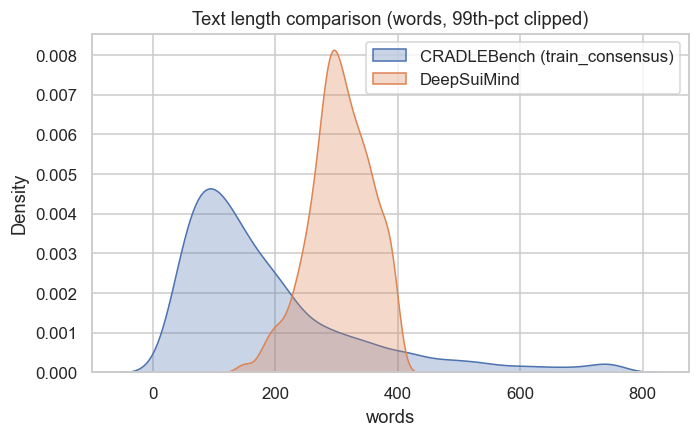

,unit,labelled rows,task,median words,source
dataset,,,,,
CRADLEBench,social-media post,8259,multi-label crisis + temporal,143,real posts + LLM-labelled
DeepSuiMind,synthetic narrative,1605,categorical (scenario/belief/intent),306,fully synthetic (psych-grounded)


In [15]:
cradle_words = frames["train_consensus"]["word_len"]
ds_words = ds["word_len"]

fig, ax = plt.subplots(figsize=(7, 4))
sns.kdeplot(cradle_words.clip(upper=cradle_words.quantile(0.99)), ax=ax,
            label="CRADLEBench (train_consensus)", fill=True, alpha=0.3)
sns.kdeplot(ds_words.clip(upper=ds_words.quantile(0.99)), ax=ax,
            label="DeepSuiMind", fill=True, alpha=0.3)
ax.set_title("Text length comparison (words, 99th-pct clipped)")
ax.set_xlabel("words"); ax.legend()
savefig(fig, "compare_text_length.png"); plt.show()

pd.DataFrame({
    "dataset": ["CRADLEBench", "DeepSuiMind"],
    "unit": ["social-media post", "synthetic narrative"],
    "labelled rows": [sum(len(f) for f in frames.values()), len(ds)],
    "task": ["multi-label crisis + temporal", "categorical (scenario/belief/intent)"],
    "median words": [int(cradle_words.median()), int(ds_words.median())],
    "source": ["real posts + LLM-labelled", "fully synthetic (psych-grounded)"],
}).set_index("dataset")

---
## Takeaways for modelling

- **CRADLEBench** is a *multi-label* problem with a strong `no_crisis` majority and a long-tailed crisis-type distribution — expect class imbalance; the temporal (ongoing/past) split doubles the effective label space and matters clinically.
- **DeepSuiMind** is fully synthetic, short-to-medium narratives with balanced categorical axes; `Intention Category` is near-constant, so its signal is mostly in `Scenario` × `Negative Core Belief`.
- The two datasets differ in unit (post vs narrative), label scheme, and provenance (real vs synthetic) — relevant when designing a shared crisis-aware adaptation pipeline.